# Tema 1

Ex. 1. Scrieţi un program în Python care să preia ca input un fişier .csv cu o listă oarecare şi să aibă ca output un număr
predeterminat de elemente din acea listă, fără repetiţie. Aplicaţi pe lista studenţilor din grupa dumneavoastră care nu
au prezentat încă o temă.

Notă: Pentru generarea unui eşantion aleator se poate apela funcţia sample din modulul random sau funcţia random.choice cu argumentul replace=False din librăria Numpy.

In [2]:
import csv
import random

def alege_elemente(fisier, nr_elemente):
    elemente = []
    with open(fisier, "r") as file:
        reader = csv.reader(file)
        for row in reader :
            elemente.append(row[0])
    if nr_elemente > len(elemente):
        print("Eroare: prea multe elemente cerute")
        return elemente
    elemente_alese = random.sample(elemente, nr_elemente)
    return elemente_alese




Ex. 2. Doi prieteni joacă următorul joc, după următoarele reguli:
Pasul 1. Primul jucător aruncă cu o monedă.
● Dacă pică stemă, cel de-al doilea trebuie să arunce cu zarul şi să-i dea primului o sumă egală z − 3 \$ , unde z
este rezultatul aruncării cu zarul (a da o sumă negativă este echivalent cu a lua opusul acelei sume). Jocul
se încheie aici.
● Dacă pică ban, atunci primul jucător trebuie să-i dea celui de-al doilea 0.5 $.
Pasul n. În caz că jocul nu s-a încheiat, se reia pasul 1.
Astfel, jocul se opreşte la pasul corespunzător obţinerii stemei de către primul jucător.

a) Ce fel de distribuţie urmează N, numărul de paşi ai jocului?

N-> nr de pasi pana la aparitia stemei. Este un experiment de tip succes/esec repetat pana se ajunge la primul succes. Astfel N urmeaza o distributie geometrica de parametru *p* (probabilitatea de a obtine stema). 

b) Simulaţi în Python un astfel de joc. Variabilele care ne interesează sunt N şi suma totală S pe care cel de-al
doilea jucător trebuie să i-o dea primului.

In [3]:
#Consideram ca moneda este nemasluita, p(stema)=p(ban)=0.5

import random
import numpy as np
import matplotlib.pyplot as plt

def simulare_joc(p=0.5):
    N = 0
    S = 0
    while True:
        N += 1
        stema = (random.random() < p)
        if stema:
            z = random.randint(1,6)
            S += (z-3)
            break
        else:
            S -= 0.5
    return N, S



c) Prin simularea unui număr mare de astfel de jocuri, determinaţi cu aproximaţie media lui S şi reprezentaţi grafic
(printr-o histogramă) distribuţia acesteia.

Simulare pentru p = 0.5:


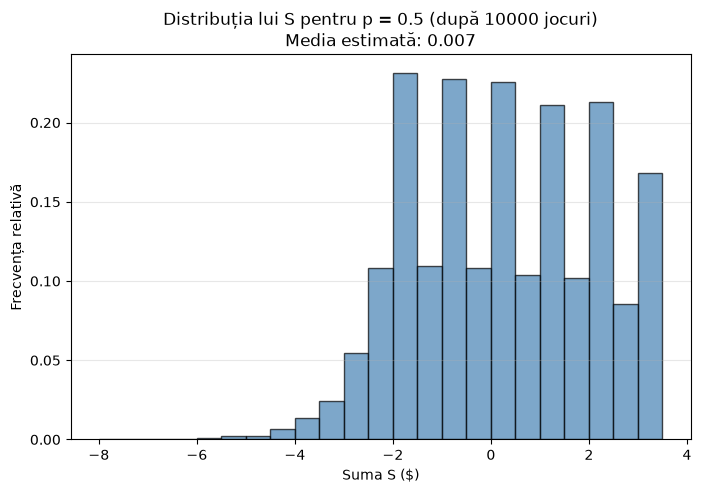

In [4]:
def simulare_multipla(nr_jocuri, p):
    rezultate = [simulare_joc(p) for i in range(nr_jocuri)]
    sume_S = [rez[1] for rez in rezultate]

    media_S = np.mean(sume_S)
    plt.figure(figsize=(8,5))
    plt.hist(sume_S, bins=np.arange(min(sume_S), max(sume_S) + 1, 0.5), 
             density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    plt.title(f"Distribuția lui S pentru p = {p} (după {nr_jocuri} jocuri)\nMedia estimată: {media_S:.3f}")
    plt.xlabel("Suma S ($)")
    plt.ylabel("Frecvența relativă")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

print("Simulare pentru p = 0.5:")
simulare_multipla(nr_jocuri=10000, p=0.5)


d) Ce se întâmplă dacă moneda este măsluită? Încercaţi să refaceţi pct. c) cu o probabilitate de apariţie a stemei
p = 0.3, respectiv p = 0.7.

Simulare pentru p = 0.3:


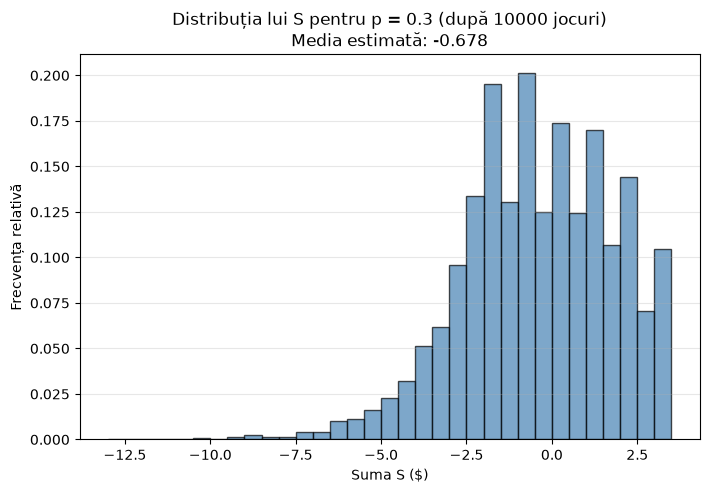

Simulare pentru p = 0.7:


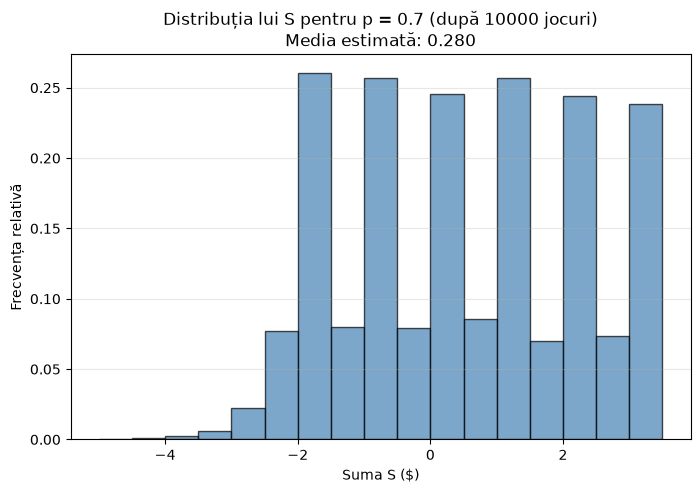

In [5]:
print("Simulare pentru p = 0.3:")
simulare_multipla(nr_jocuri=10000, p=0.3)

print("Simulare pentru p = 0.7:")
simulare_multipla(nr_jocuri=10000, p=0.7)

Ex. 3. Într-o frizerie, trei frizeri îşi tund clienţii cu următoarele viteze medii: primul cu 3 clienţi pe oră, al doilea cu 6 pe
oră iar al treilea cu 4 pe oră. Astfel, timpul de servire al unui client este modelat de distribuţii exponenţiale cu parametrii
λ1 = 3 h−1, λ2 = 6 h−1, respectiv λ3 = 4 h−1, iar probabilităţile de preluare a unui client de către un anumit frizer sunt 3/13, 6/13, respectiv 4/13 (de ce?). Fie X timpul de servire pentru un client.

Generaţi 10000 de valori pentru X, şi în felul acesta estimaţi media şi deviaţia standard a lui X. Realizaţi un grafic
aproximativ al densităţii distribuţiei lui X.

Notă: Distribuţia Exp(λ) se poate apela prin random.exponential(scale=1/λ) în Numpy, sau cu stats.expon(scale=1/λ)
în Scipy. Având în vedere că X are o distribuţie continuă, densitatea aproximativă acesteia se poate vizualiza folosind
funcţia plot_kde din librăria Arviz.

Media estimată a lui X: 0.2321 ore
Deviația standard estimată a lui X: 0.2486 ore


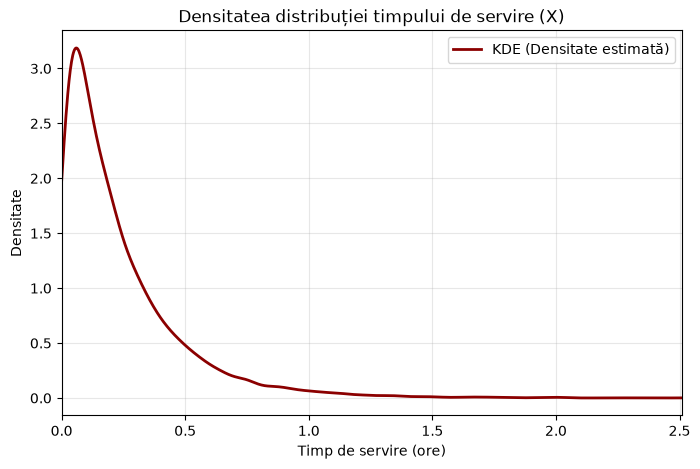

In [ ]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

lambdas = np.array([3, 6, 4])
probabilitati = np.array([3/13, 6/13, 4/13])
n_clienti = 10000

frizeri_alesi = np.random.choice([0, 1, 2], size=n_clienti, p=probabilitati)

scale_ales = 1 / lambdas[frizeri_alesi]

X = np.random.exponential(scale=scale_ales)

media_estimata = np.mean(X)
deviatia_std_estimata = np.std(X)

print(f"Media estimată a lui X: {media_estimata:.4f} ore")
print(f"Deviația standard estimată a lui X: {deviatia_std_estimata:.4f} ore")

kde = gaussian_kde(X)
x_grid = np.linspace(0, max(X), 1000) 
densitate = kde(x_grid)              

plt.figure(figsize=(8, 5))
plt.plot(x_grid, densitate, label='KDE (Densitate estimată)', color='darkred', linewidth=2)

plt.title("Densitatea distribuției timpului de servire (X)")
plt.xlabel("Timp de servire (ore)")
plt.ylabel("Densitate")
plt.xlim(0, max(X))
plt.grid(alpha=0.3)
plt.legend()
plt.show()